# Car Price Prediction using Machine Learning

## Objective
The objective of this project is to predict the selling price of used cars using machine learning techniques.

## Dataset
This dataset contains information about used cars such as manufacturing year, present price, kilometers driven, fuel type, transmission type, and ownership details.

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Exploratory Data Analysis (EDA)

In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [8]:
print(df['Fuel_Type'].unique())
print(df['Selling_type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


## Feature Engineering

In [9]:
df['Car_Age'] = 2025 - df['Year']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


In [10]:
df.drop('Year', axis=1, inplace=True)

## Data Visualization

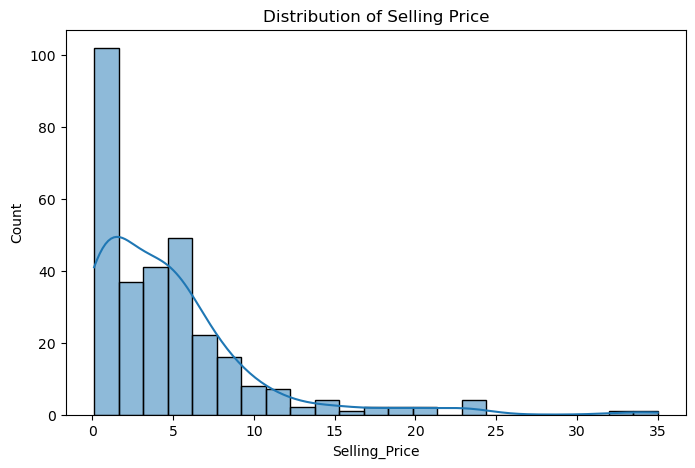

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')
plt.show()

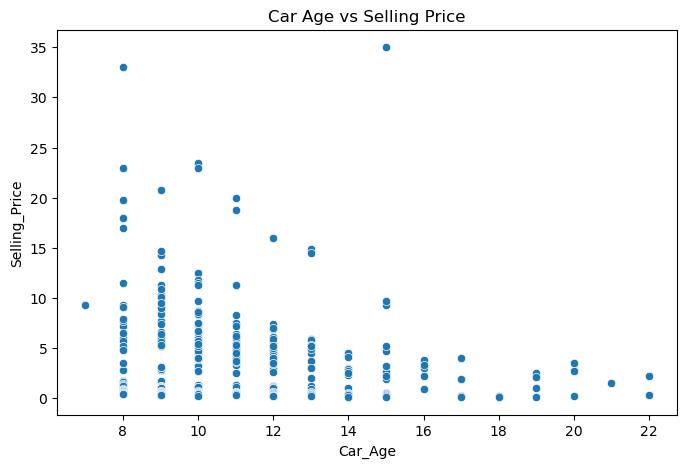

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)
plt.title('Car Age vs Selling Price')
plt.show()

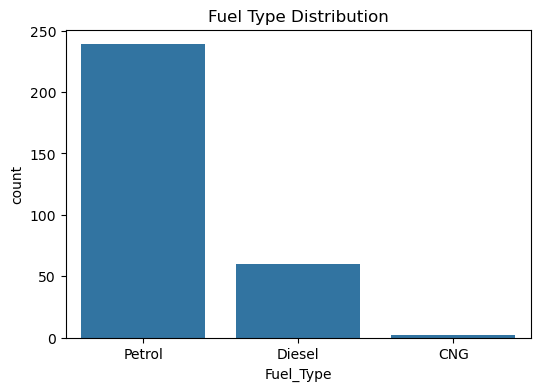

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Fuel_Type', data=df)
plt.title('Fuel Type Distribution')
plt.show()

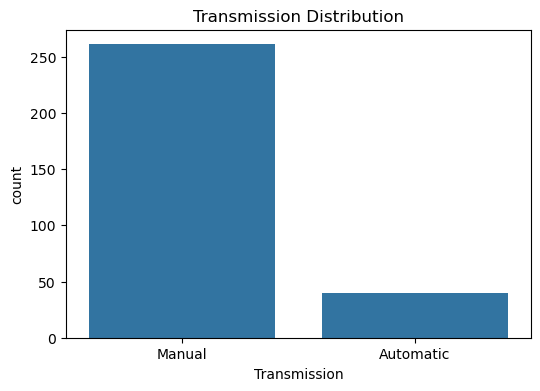

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Transmission', data=df)
plt.title('Transmission Distribution')
plt.show()

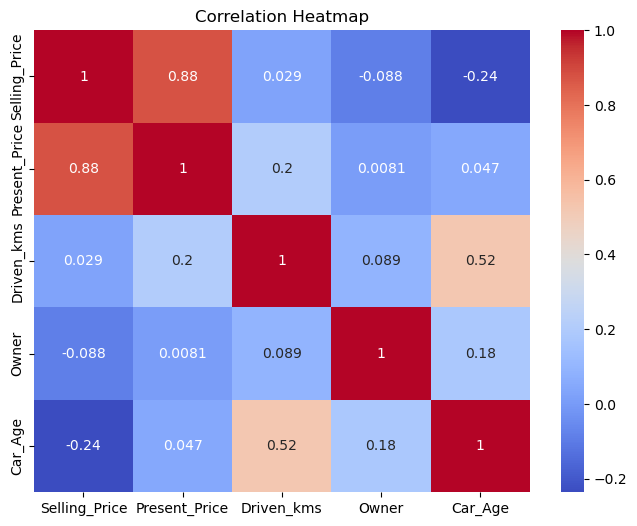

In [15]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
df.drop('Car_Name', axis=1, inplace=True)

In [17]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


In [18]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred_lr = lr.predict(X_test)

In [22]:
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

R2 Score: 0.8488707839193155
MAE: 1.2163740193330348


In [23]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2 Score: 0.9594566919773236
MAE: 0.6368655737704919


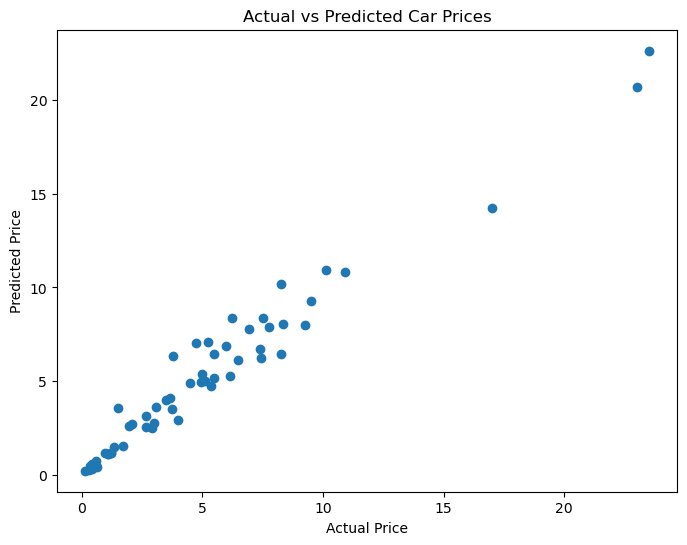

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.savefig("actual_vs_predicted.png")
plt.show()

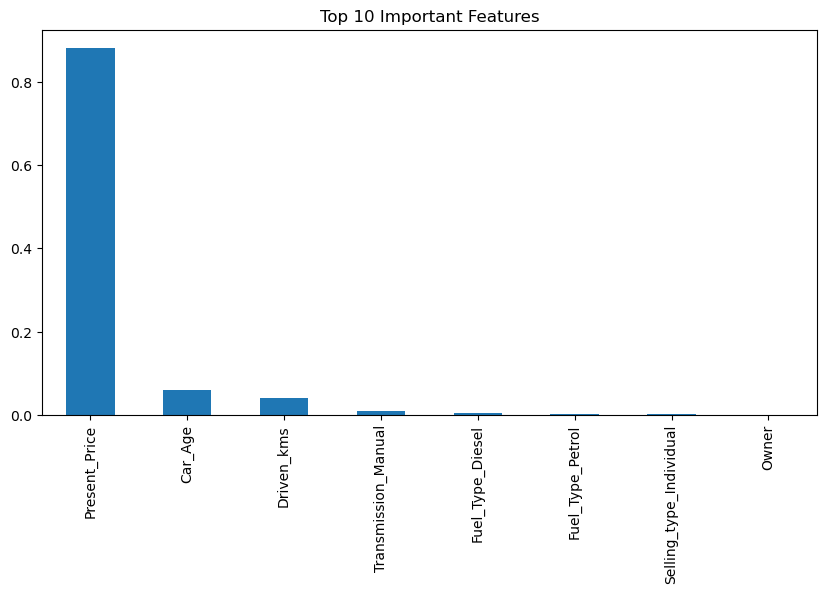

In [25]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)
plt.savefig("feature_importance.png")
plt.title("Top 10 Important Features")
plt.show()

In [26]:
sample_predictions = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
})

sample_predictions.head(10)

,Actual Price,Predicted Price
0,0.35,0.4438
1,10.11,10.9098
2,4.95,4.9315
3,0.15,0.2159
4,6.95,7.7988
5,7.45,6.2535
6,1.10,1.1065
7,0.50,0.5876
8,0.45,0.4690
9,6.00,6.8960


# Conclusion

In this project, machine learning techniques were used to predict used car selling prices.

The dataset was cleaned, analyzed, and transformed using feature engineering techniques. A new feature, Car_Age, was created to improve model performance.

Two machine learning models were trained and evaluated:
1. Linear Regression
2. Random Forest Regressor

The Random Forest Regressor achieved the best performance with:
- R² Score: 0.9595
- MAE: 0.637

Feature importance analysis showed that Present_Price was the most influential factor affecting the selling price, followed by Car_Age and Driven_kms.

Therefore, Random Forest Regressor was selected as the final model for car price prediction due to its high accuracy and low prediction error.